# Análisis


In [4]:
#
import pandas as pd
pd.set_option('display.max_columns', None)

# 
import numpy as np

# 
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# 
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#lectura csv final
df_final = pd.read_csv('files/hr_final.csv', index_col = 0)
df_final.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
EmployeeNumber,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,41,True,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993.0,19479,8,True,11,3,1,0,8,0,1,6,4,0,5
2,49,False,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130.0,24907,1,False,23,4,4,1,10,3,3,10,7,1,7
4,37,True,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090.0,2396,6,True,15,3,2,0,7,3,3,0,0,0,0
5,33,False,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909.0,23159,1,True,11,3,3,0,8,3,3,8,7,3,0
7,27,False,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468.0,16632,9,False,12,3,4,1,6,3,3,2,2,2,2


In [6]:
df_final.info()

<class 'pandas.DataFrame'>
Index: 1470 entries, 1 to 2068
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   int64  
 1   Attrition                 1470 non-null   bool   
 2   BusinessTravel            1470 non-null   str    
 3   DailyRate                 1470 non-null   int64  
 4   Department                1470 non-null   str    
 5   DistanceFromHome          1470 non-null   int64  
 6   Education                 1470 non-null   int64  
 7   EducationField            1470 non-null   str    
 8   EnvironmentSatisfaction   1470 non-null   int64  
 9   Gender                    1470 non-null   str    
 10  HourlyRate                1470 non-null   int64  
 11  JobInvolvement            1470 non-null   int64  
 12  JobLevel                  1470 non-null   int64  
 13  JobRole                   1470 non-null   str    
 14  JobSatisfaction         

In [7]:
#Función para calcular el resumen estadístico de una variable:

def resumen_variable(df, columna):

    serie_original = df[columna]
    serie = serie_original.dropna()

    media = serie.mean()
    mediana = serie.median()
    moda = serie.mode()
    desviacion = serie.std()
    minimo = serie.min()
    maximo = serie.max()
    varianza = serie.var()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    rango_intercuartilico = q3 - q1
    rango = maximo - minimo

    if media != 0:
        coef_variacion = (desviacion / media) * 100
    else:
        coef_variacion = np.nan

    resumen = pd.DataFrame({
        "variable": [columna],
        "media": [round(media, 2)],
        "mediana": [round(mediana, 2)],
        "moda": [moda.iloc[0] if len(moda) > 0 else np.nan],
        "desviacion_estandar": [round(desviacion, 2)],
        "minimo": [round(minimo, 2)],
        "maximo": [round(maximo, 2)],
        "varianza": [round(varianza, 2)],
        "q1": [round(q1, 2)],
        "q3": [round(q3, 2)],
        "rango_intercuartilico": [round(rango_intercuartilico, 2)],
        "rango": [round(rango, 2)],
        "coeficiente_variacion": [round(coef_variacion, 2)]
    })

    return resumen

In [8]:
#Hacemos una función para automatizar que nos saque toda la información de cada variable numérica
def resumen_variables_numericas(df, columnas_numericas):

    tablas_resumen = []

    for columna in columnas_numericas:
        resumen = resumen_variable(df, columna)
        tablas_resumen.append(resumen)

    resumen_total = pd.concat(tablas_resumen, ignore_index=True)

    return resumen_total

In [9]:
#Hacemos una lista de las variables numéricas
variables_numericas = df_final.select_dtypes(include=["int64", "float64"]).columns.tolist()

variables_numericas

['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [10]:
resumen_total = resumen_variables_numericas(df_final, variables_numericas)
resumen_total

,variable,media,mediana,moda,desviacion_estandar,minimo,maximo,varianza,q1,q3,rango_intercuartilico,rango,coeficiente_variacion
0,Age,36.95,36.0,37.0,8.87,18.0,60.0,78.62,31.00,42.00,11.00,42.0,24.00
1,DailyRate,802.49,802.0,691.0,403.51,102.0,1499.0,162819.59,465.00,1157.00,692.00,1397.0,50.28
2,DistanceFromHome,9.19,7.0,2.0,8.11,1.0,29.0,65.72,2.00,14.00,12.00,28.0,88.19
3,Education,2.91,3.0,3.0,1.02,1.0,5.0,1.05,2.00,4.00,2.00,4.0,35.16
4,EnvironmentSatisfaction,2.72,3.0,3.0,1.09,1.0,4.0,1.19,2.00,4.00,2.00,3.0,40.16
5,HourlyRate,65.89,66.0,66.0,20.33,30.0,100.0,413.29,48.00,83.75,35.75,70.0,30.85
6,JobInvolvement,2.73,3.0,3.0,0.71,1.0,4.0,0.51,2.00,3.00,1.00,3.0,26.07
7,JobLevel,2.06,2.0,1.0,1.11,1.0,5.0,1.23,1.00,3.00,2.00,4.0,53.63
8,JobSatisfaction,2.74,3.0,3.0,1.09,1.0,4.0,1.20,2.00,4.00,2.00,3.0,39.99
9,MonthlyIncome,6483.52,4907.0,4907.0,4689.45,1009.0,19999.0,21990945.44,2926.75,8233.75,5307.00,18990.0,72.33


## Variables categóricas


In [11]:
#Creamos lista para variables categóricas
variables_categoricas = df_final.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

variables_categoricas

['Attrition',
 'BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'OverTime']

In [12]:
len(variables_categoricas)

8

In [13]:
#Función para extraer la frecuencia absoluta y relativa de cada variable categórica
def tablas_categoricas(df, columnas_categoricas):
    tablas = {}

    for columna in columnas_categoricas:
        frecuencia_absoluta = df[columna].value_counts(dropna=False)
        frecuencia_relativa = df[columna].value_counts(normalize=True, dropna=False) * 100

        tabla = pd.DataFrame({
            "frecuencia_absoluta": frecuencia_absoluta,
            "frecuencia_relativa": frecuencia_relativa.round(2)
        })

        tabla.index.name = columna
        tablas[columna] = tabla

        print(f"\nVariable: {columna}")
        display(tabla)

In [14]:
tablas_categoricas(df_final, variables_categoricas)


Variable: Attrition


,frecuencia_absoluta,frecuencia_relativa
Attrition,,
False,1233,83.88
True,237,16.12



Variable: BusinessTravel


,frecuencia_absoluta,frecuencia_relativa
BusinessTravel,,
Travel_Rarely,951,64.69
Travel_Frequently,263,17.89
Non-Travel,139,9.46
unknown,117,7.96



Variable: Department


...

,frecuencia_absoluta,frecuencia_relativa
JobRole,,
Sales Executive,326,22.18
Research Scientist,292,19.86
Laboratory Technician,259,17.62
Manufacturing Director,145,9.86
Healthcare Representative,131,8.91
Manager,102,6.94
Sales Representative,83,5.65
Research Director,80,5.44
Human Resources,52,3.54



Variable: MaritalStatus


,frecuencia_absoluta,frecuencia_relativa
MaritalStatus,,
Married,606,41.22
Single,436,29.66
Divorced,296,20.14
unknown,132,8.98



Variable: OverTime


,frecuencia_absoluta,frecuencia_relativa
OverTime,,
False,1065,72.45
True,405,27.55


## columnas numericas
YearsSinceLastPromotion
YearsAtCompany
TotalWorkingYears
MonthlyIncome
MonthlyIncome

## columnas de encuesta
EnvironmentSatisfaction
RelationshipSatisfaction
JobInvolvement
JobSatisfaction
WorkLifeBalance

#
BusinessTravel
Department
DistanceFromHome
JobLevel
StockOptionLevel
 
TrainingTimesLastYear

PercentSalaryHike

In [15]:
#División de variables numéricas en diferentes listas, para mejorar la visualización

variables_numericas1 = ['DistanceFromHome','JobLevel','PerformanceRating','StockOptionLevel','TrainingTimesLastYear']
variables_numericas2= ['Age', 'Education','NumCompaniesWorked']
variables_encuesta = ['EnvironmentSatisfaction', 'JobInvolvement','JobSatisfaction','RelationshipSatisfaction','WorkLifeBalance']
variables_salario = ['DailyRate','HourlyRate', 'MonthlyRate','MonthlyIncome','PercentSalaryHike']
variables_tiempo = [ 'TotalWorkingYears','YearsAtCompany','YearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager']

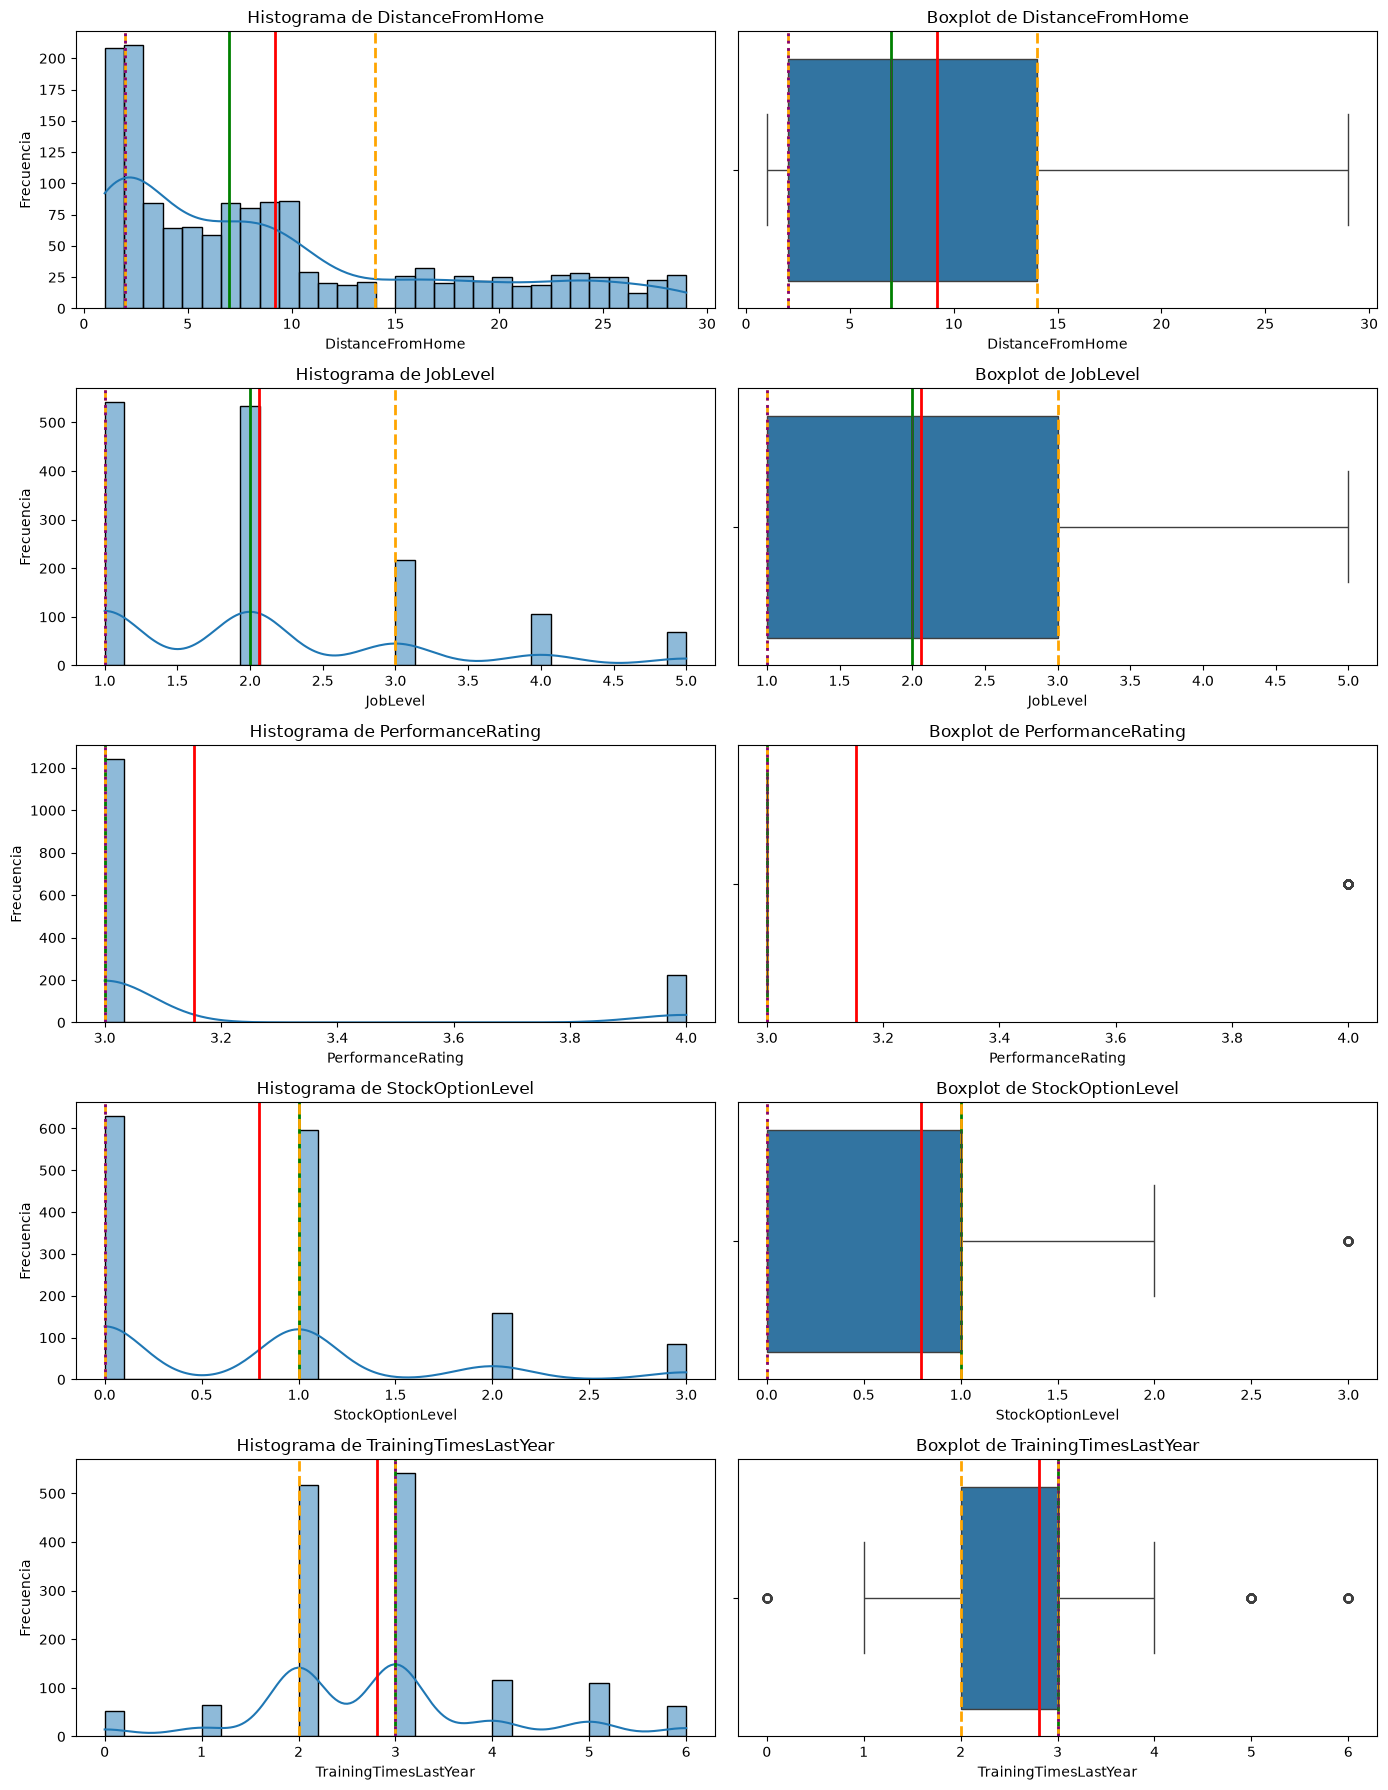

In [17]:
#Visualización de variables_numericas1

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 18))

for i, variable in enumerate(variables_numericas1):

    media = df_final[variable].mean()
    mediana = df_final[variable].median()
    q1 = df_final[variable].quantile(0.25)
    q3 = df_final[variable].quantile(0.75)
    moda = df_final[variable].mode()[0]
    
    # Histograma
    sns.histplot(
        data=df_final,
        x=variable,
        bins=30,
        kde=True,
        ax=axes[i, 0]
    )

    axes[i, 0].axvline(media, color="red", linestyle="-", linewidth=2, label=f"Media: {media:.2f}")
    axes[i, 0].axvline(mediana, color="green", linestyle="-", linewidth=2, label=f"Mediana: {mediana:.2f}")
    axes[i, 0].axvline(q1, color="orange", linestyle="--", linewidth=2, label=f"Q1: {q1:.2f}")
    axes[i, 0].axvline(q3, color="orange", linestyle="--", linewidth=2, label=f"Q3: {q3:.2f}")
    axes[i, 0].axvline(moda, color="purple", linestyle=":", linewidth=2, label=f"Moda: {moda:.2f}")
    
    axes[i, 0].set_title(f"Histograma de {variable}")
    axes[i, 0].set_xlabel(variable)
    axes[i, 0].set_ylabel("Frecuencia")
    
    
    # Boxplot
    sns.boxplot(
        data=df_final,
        x=variable,
        ax=axes[i, 1]
    )
    axes[i, 1].axvline(media, color="red", linestyle="-", linewidth=2, label=f"Media: {media:.2f}")
    axes[i, 1].axvline(mediana, color="green", linestyle="-", linewidth=2, label=f"Mediana: {mediana:.2f}")
    axes[i, 1].axvline(q1, color="orange", linestyle="--", linewidth=2, label=f"Q1: {q1:.2f}")
    axes[i, 1].axvline(q3, color="orange", linestyle="--", linewidth=2, label=f"Q3: {q3:.2f}")
    axes[i, 1].axvline(moda, color="purple", linestyle=":", linewidth=2, label=f"Moda: {moda:.2f}")

    axes[i, 1].set_title(f"Boxplot de {variable}")
    axes[i, 1].set_xlabel(variable)

plt.tight_layout()
plt.show()

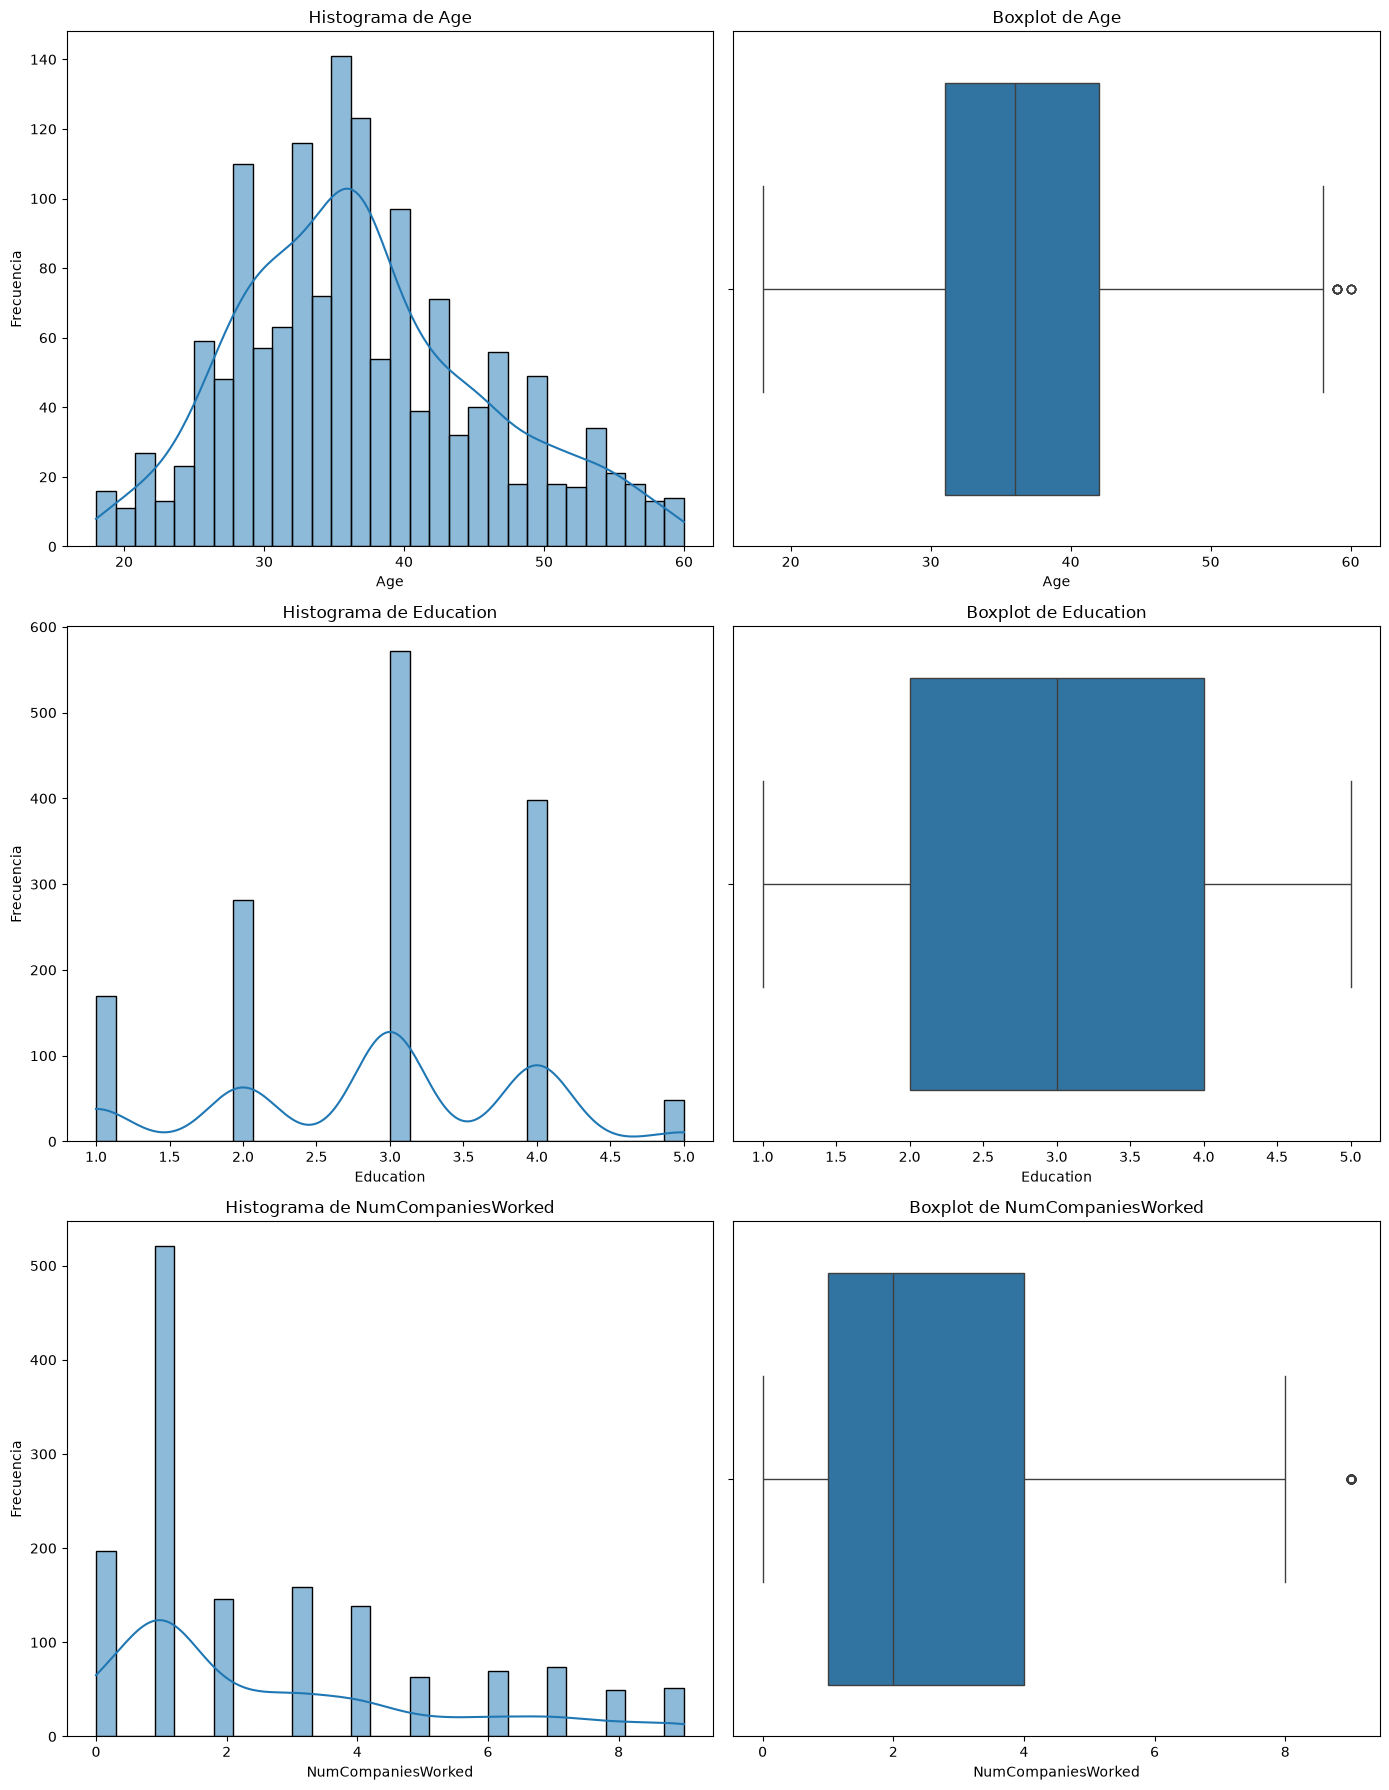

In [24]:
#Visualización de variables_numericas2

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 18))

for i, variable in enumerate(variables_numericas2):
    
    # Histograma
    sns.histplot(
        data=df_final,
        x=variable,
        bins=30,
        kde=True,
        ax=axes[i, 0]
    )
    
    axes[i, 0].set_title(f"Histograma de {variable}")
    axes[i, 0].set_xlabel(variable)
    axes[i, 0].set_ylabel("Frecuencia")
    
    
    # Boxplot
    sns.boxplot(
        data=df_final,
        x=variable,
        ax=axes[i, 1]
    )
    
    axes[i, 1].set_title(f"Boxplot de {variable}")
    axes[i, 1].set_xlabel(variable)

plt.tight_layout()
plt.show()

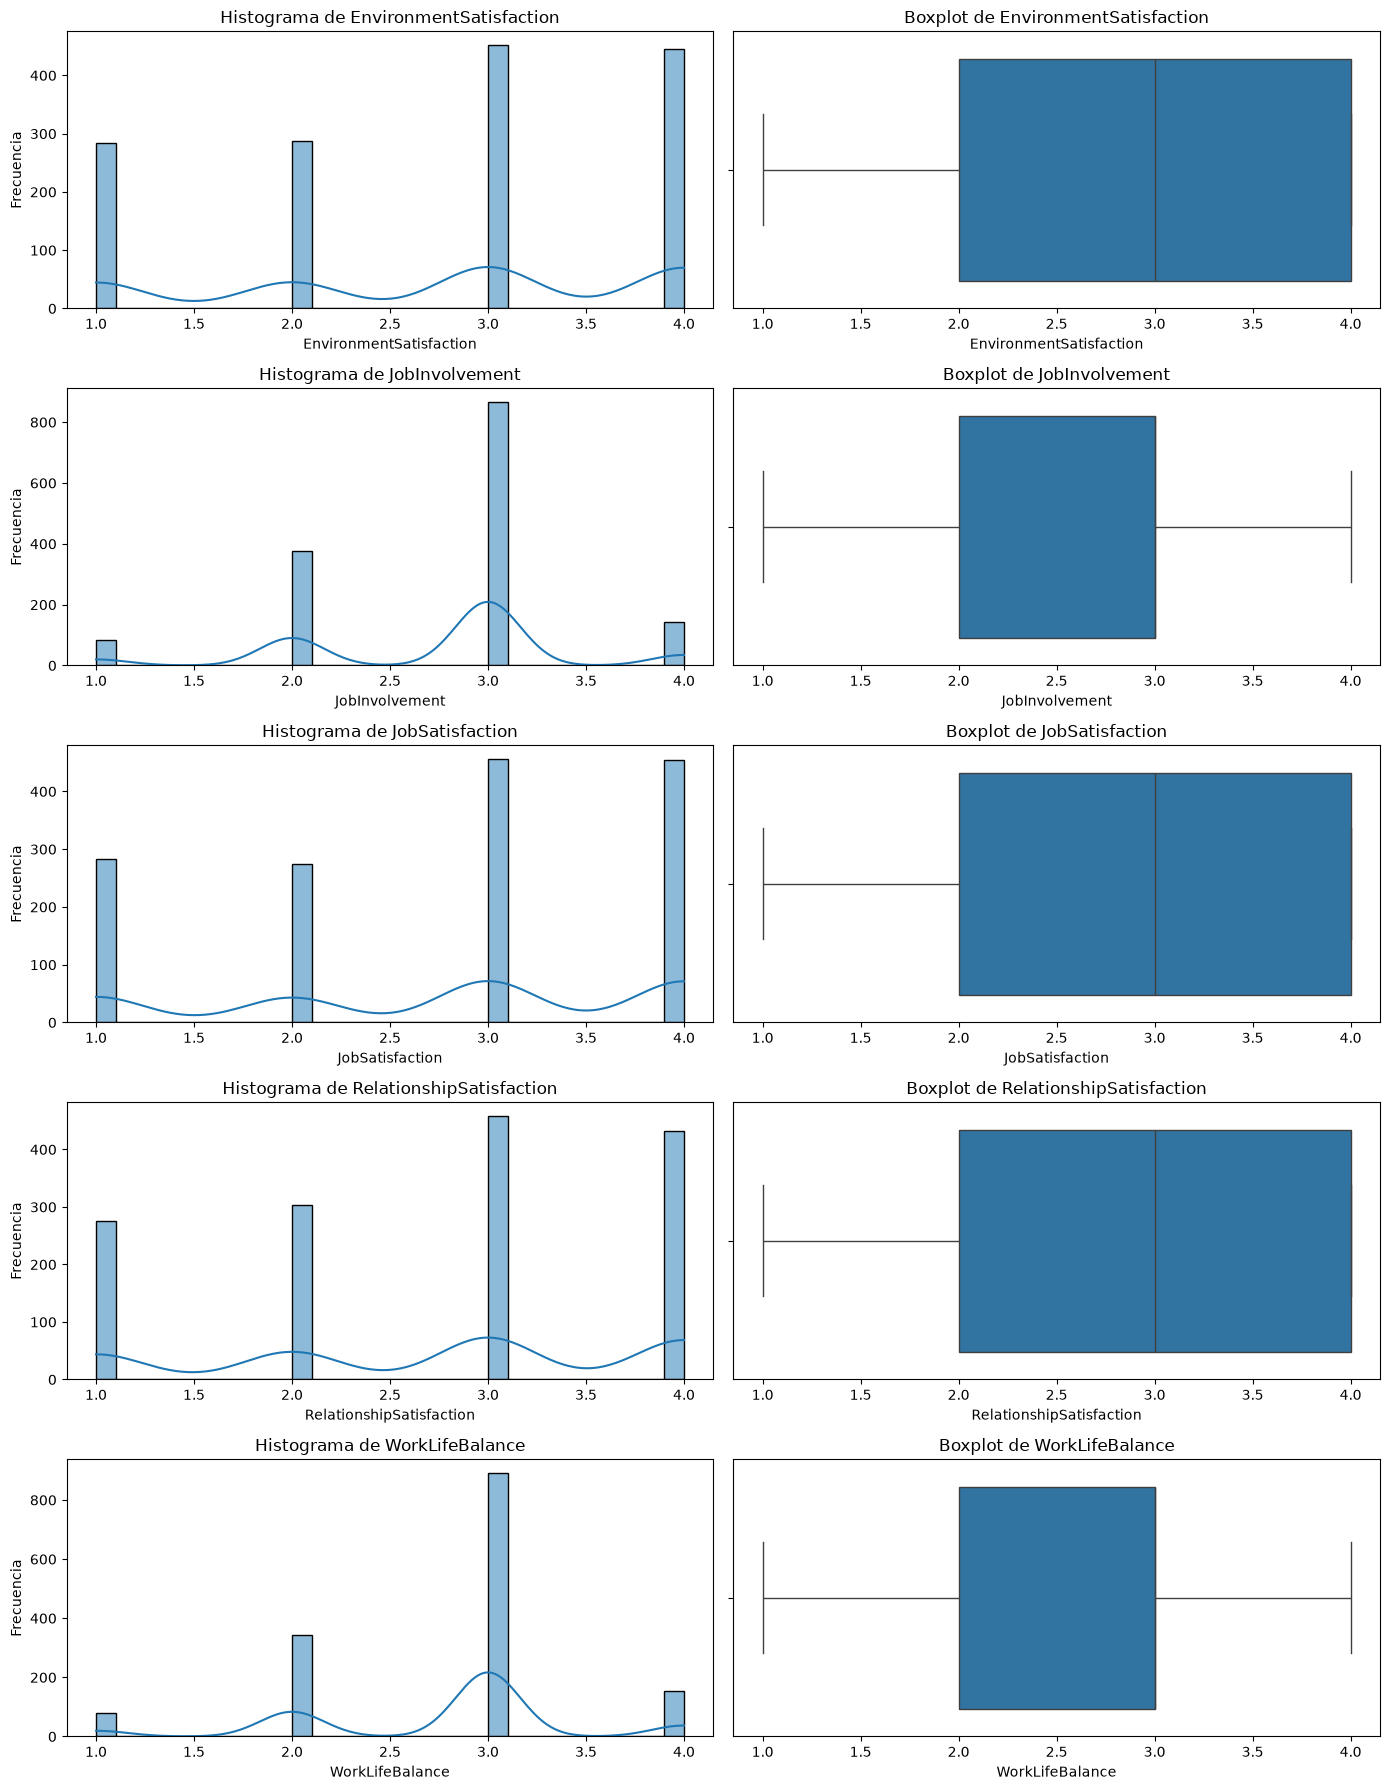

In [25]:
#Visualización de variables_encuesta

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 18))

for i, variable in enumerate(variables_encuesta):
    
    # Histograma
    sns.histplot(
        data=df_final,
        x=variable,
        bins=30,
        kde=True,
        ax=axes[i, 0]
    )
    
    axes[i, 0].set_title(f"Histograma de {variable}")
    axes[i, 0].set_xlabel(variable)
    axes[i, 0].set_ylabel("Frecuencia")
    
    
    # Boxplot
    sns.boxplot(
        data=df_final,
        x=variable,
        ax=axes[i, 1]
    )
    
    axes[i, 1].set_title(f"Boxplot de {variable}")
    axes[i, 1].set_xlabel(variable)

plt.tight_layout()
plt.show()

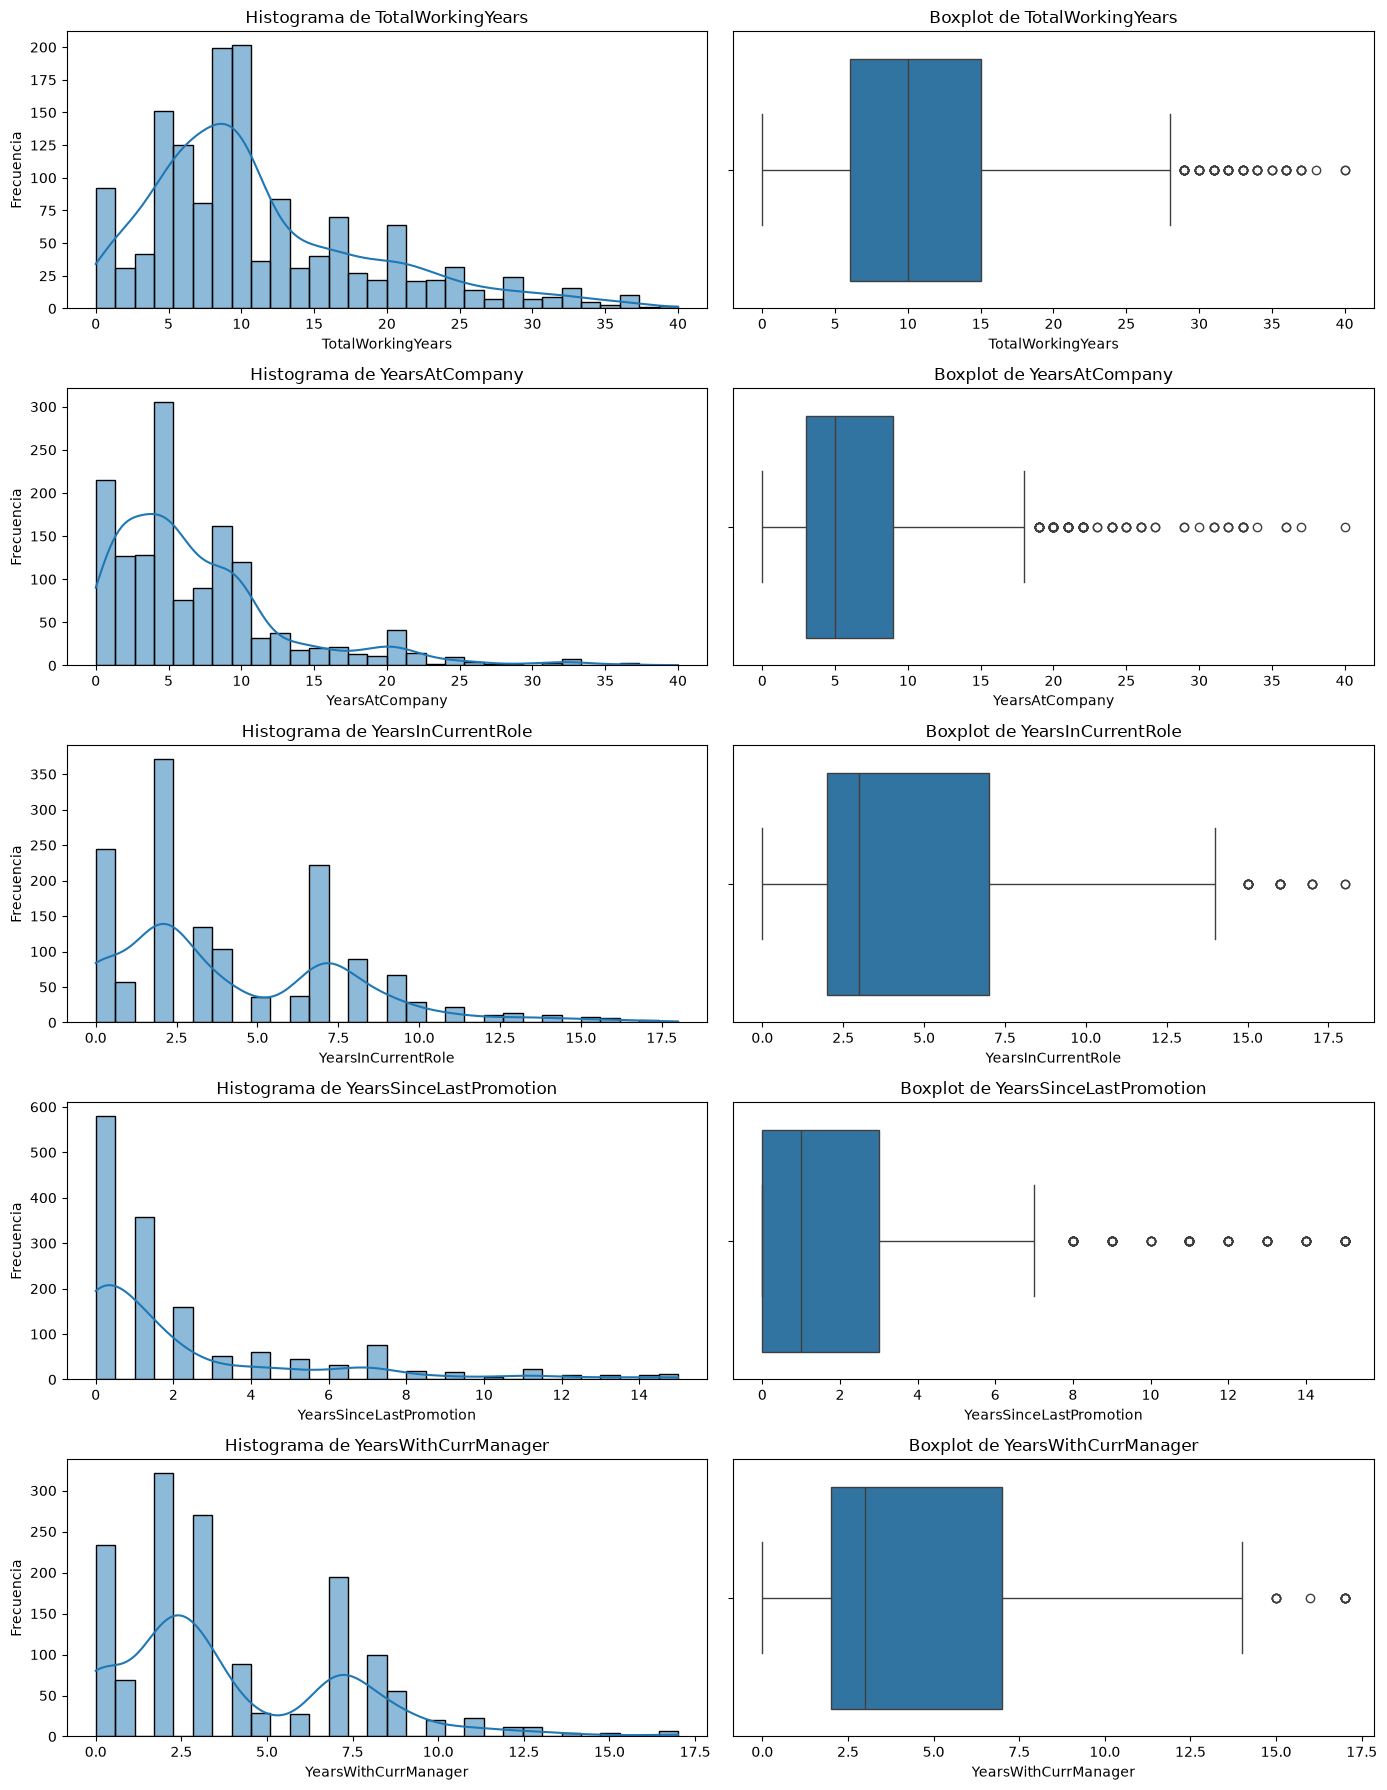

In [26]:
#Visualización de variables_tiempo

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 18))

for i, variable in enumerate(variables_tiempo):
    
    # Histograma
    sns.histplot(
        data=df_final,
        x=variable,
        bins=30,
        kde=True,
        ax=axes[i, 0]
    )
    
    axes[i, 0].set_title(f"Histograma de {variable}")
    axes[i, 0].set_xlabel(variable)
    axes[i, 0].set_ylabel("Frecuencia")
    
    
    # Boxplot
    sns.boxplot(
        data=df_final,
        x=variable,
        ax=axes[i, 1]
    )
    
    axes[i, 1].set_title(f"Boxplot de {variable}")
    axes[i, 1].set_xlabel(variable)

plt.tight_layout()
plt.show()

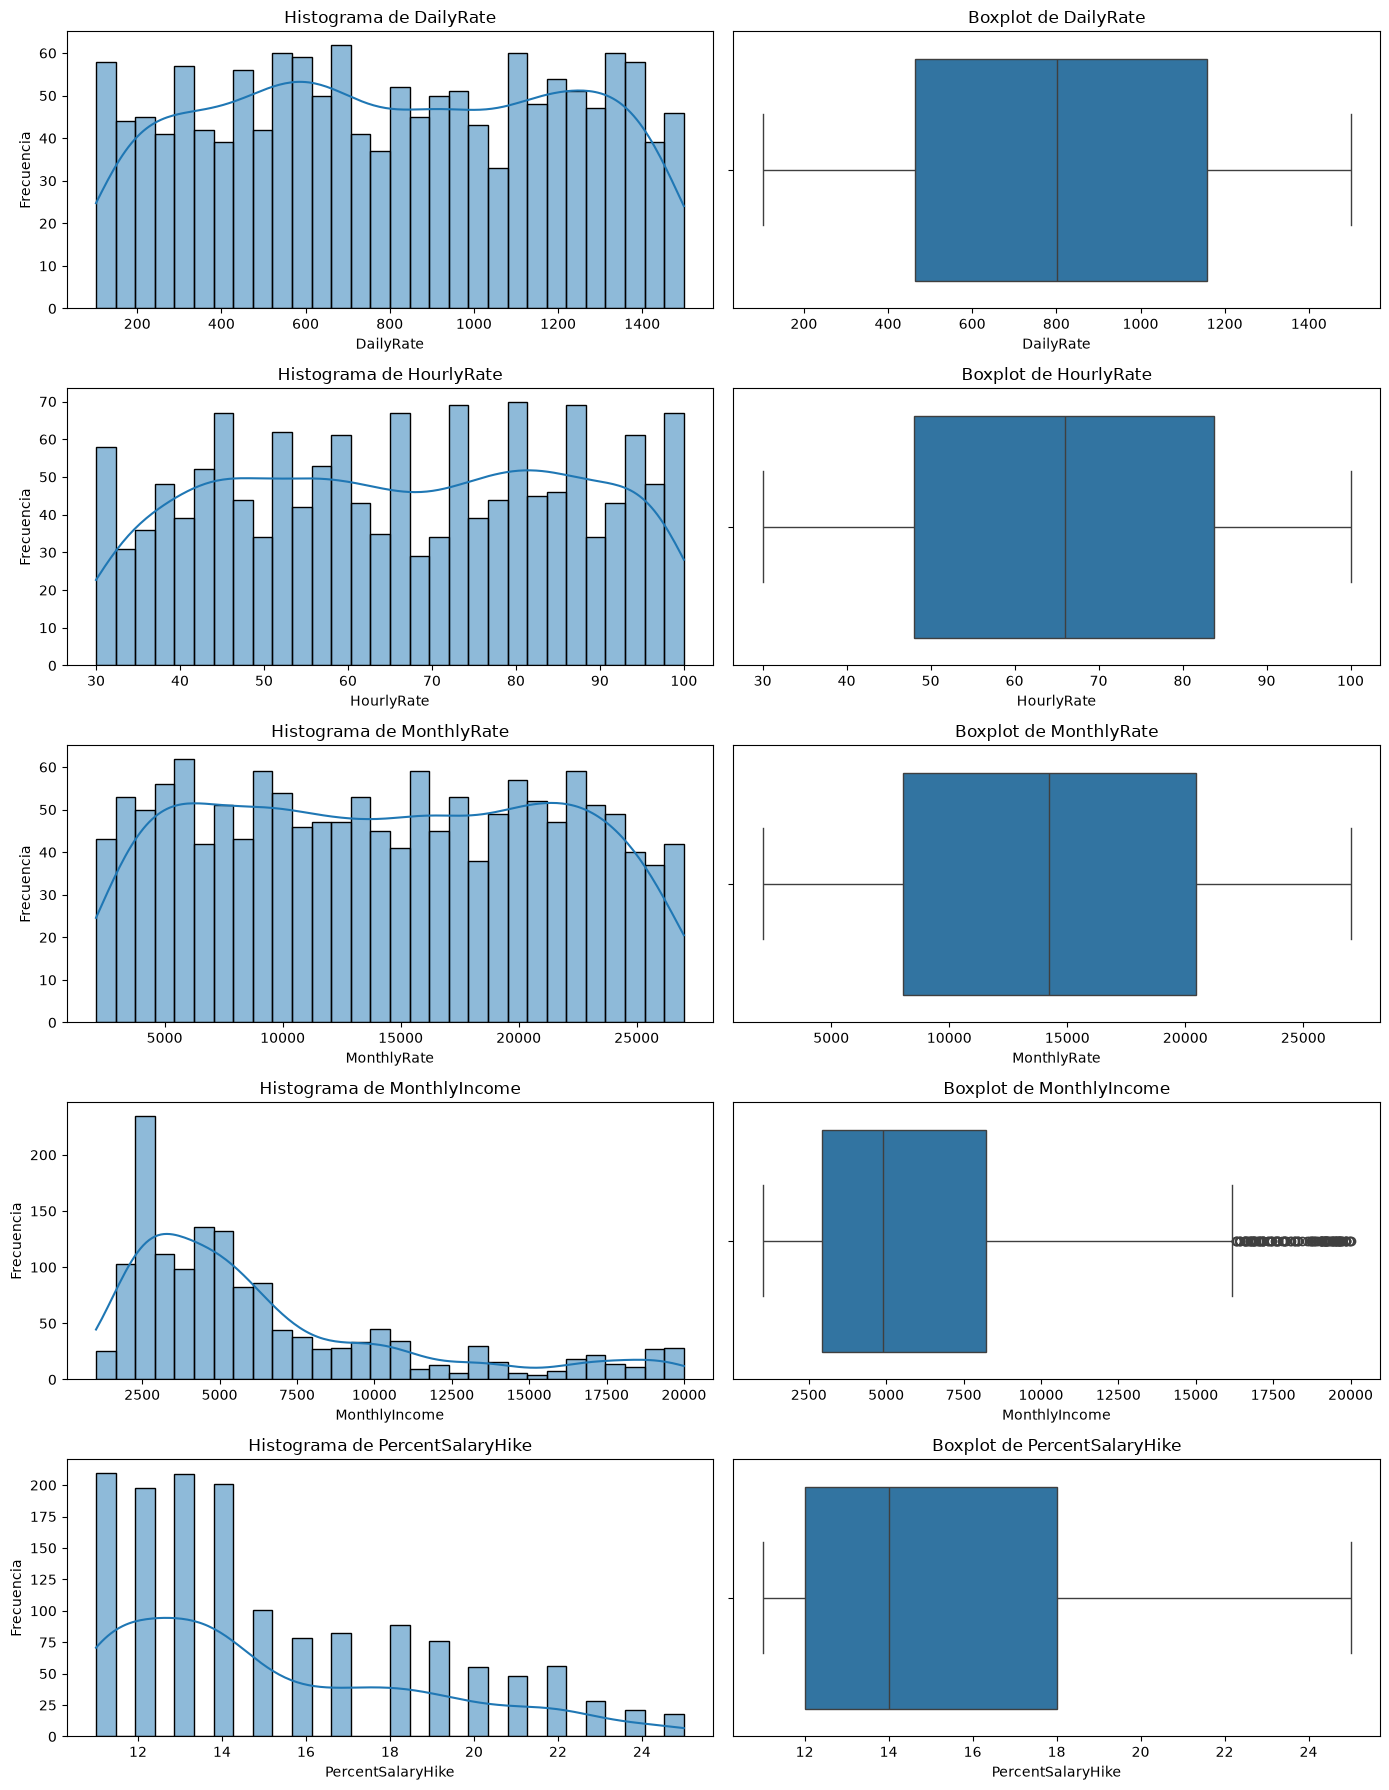

In [27]:
#Visualización de variables_salario

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 18))

for i, variable in enumerate(variables_salario):
    
    # Histograma
    sns.histplot(
        data=df_final,
        x=variable,
        bins=30,
        kde=True,
        ax=axes[i, 0]
    )
    
    axes[i, 0].set_title(f"Histograma de {variable}")
    axes[i, 0].set_xlabel(variable)
    axes[i, 0].set_ylabel("Frecuencia")
    
    
    # Boxplot
    sns.boxplot(
        data=df_final,
        x=variable,
        ax=axes[i, 1]
    )
    
    axes[i, 1].set_title(f"Boxplot de {variable}")
    axes[i, 1].set_xlabel(variable)

plt.tight_layout()
plt.show()

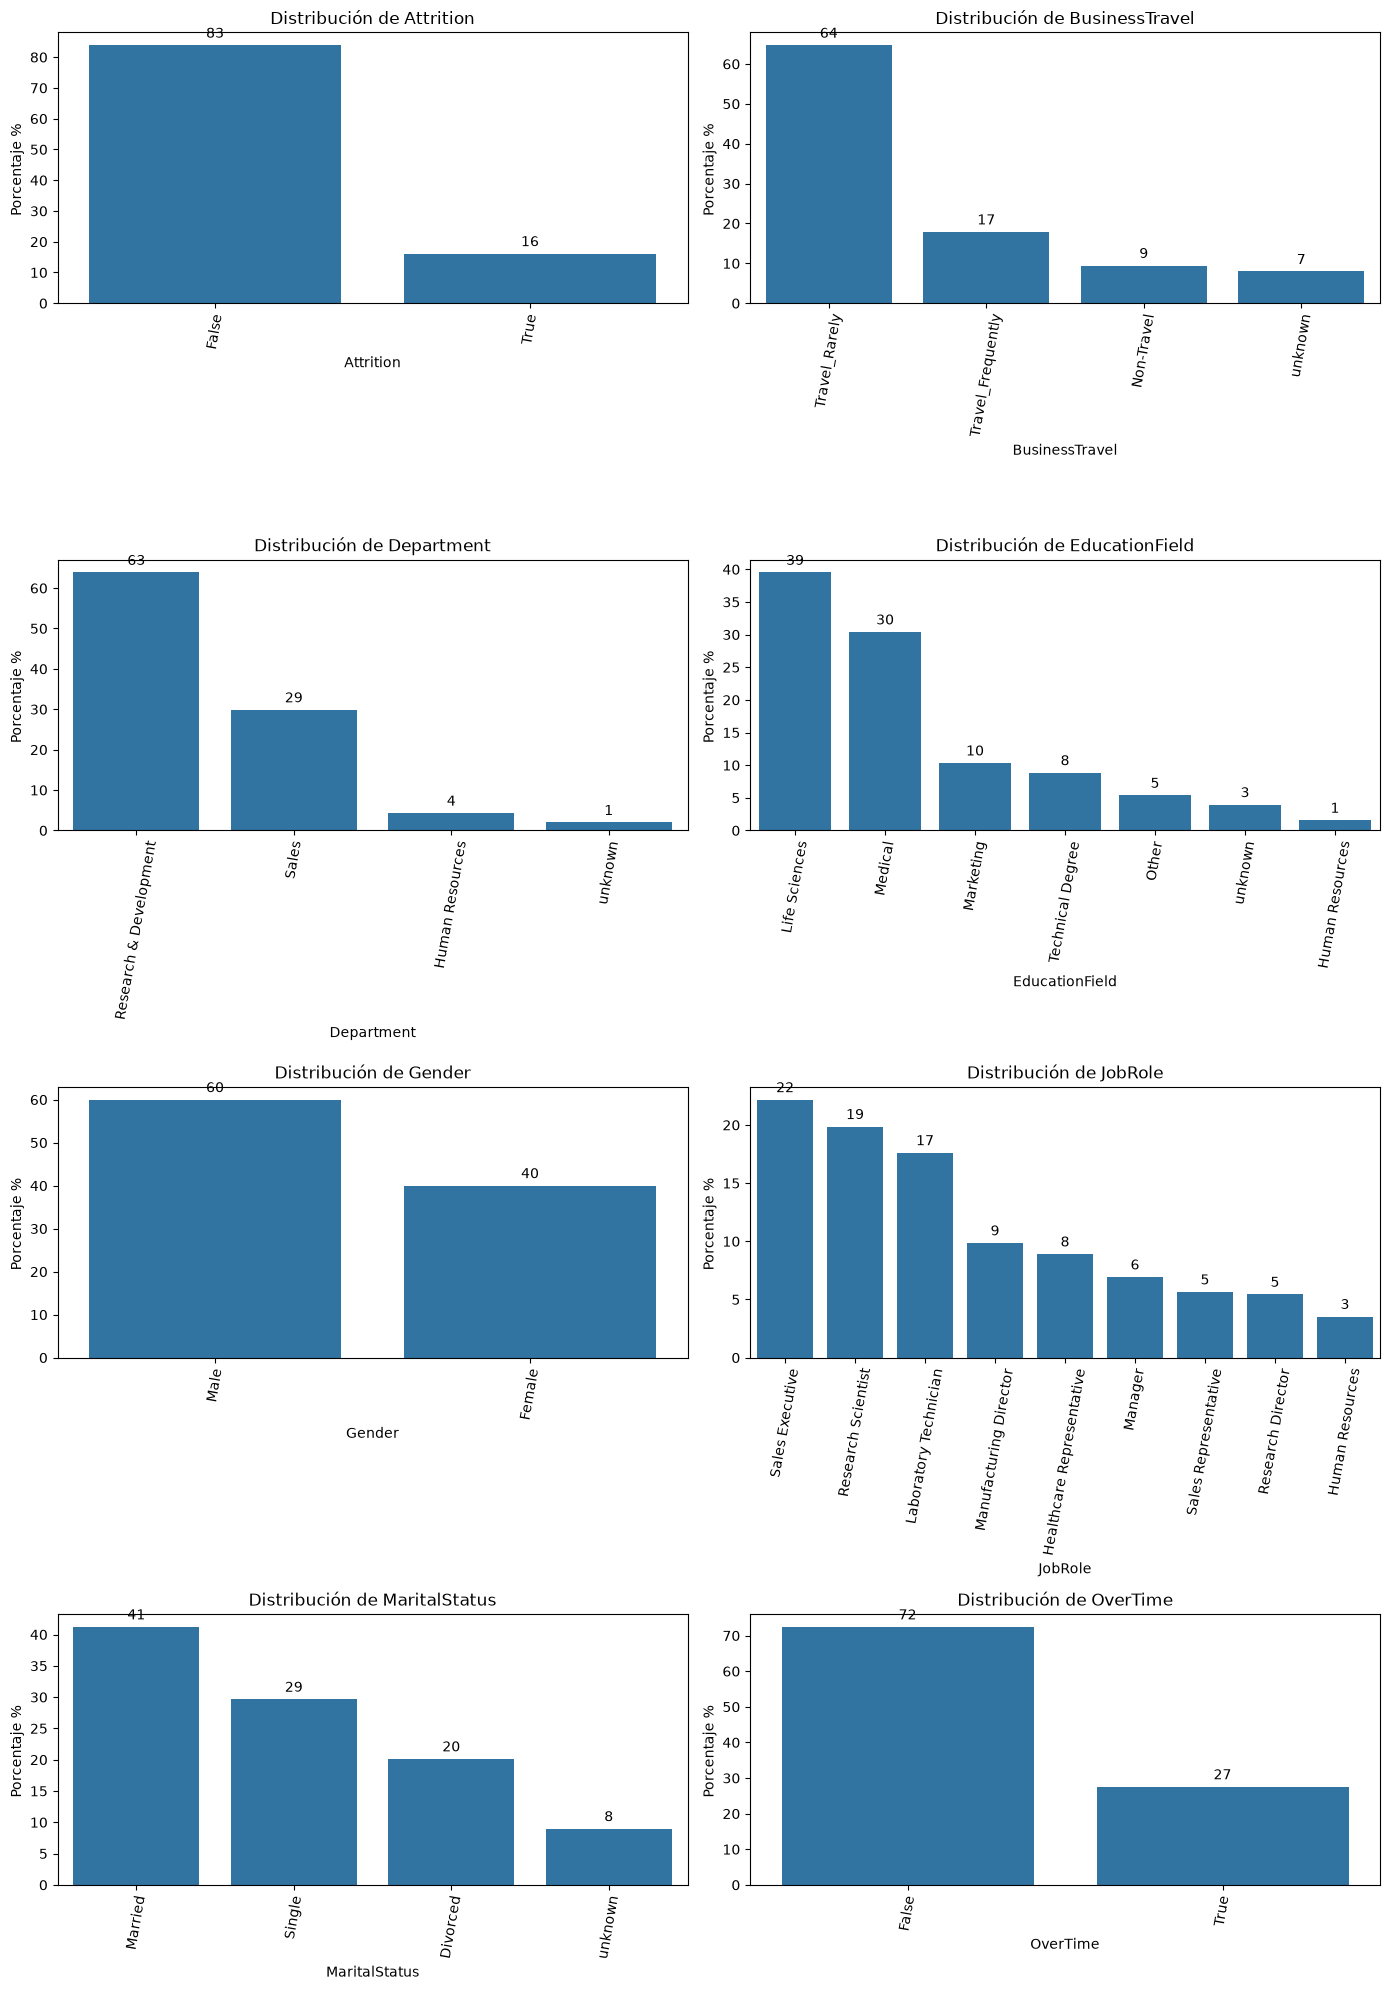

In [36]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14,20))

# Aplanamos los ejes para recorrerlos más fácilmente
axes = axes.flat

for i, columna in enumerate(variables_categoricas):

    porcentajes = (
        df_final[columna]
        .value_counts(normalize=True)
        .mul(100)
        .reset_index()
    )
    
    porcentajes.columns = [columna, "porcentaje"]
    
    
    orden = df_final[columna].value_counts().index
    
    sns.barplot(
        data=porcentajes,
        x=columna,
        y='porcentaje',
        order=orden,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Distribución de {columna}", fontsize=12)
    axes[i].set_xlabel(columna)
    axes[i].set_ylabel("Porcentaje % ")
    axes[i].tick_params(axis="x", rotation=80)
    
    # Añadir etiquetas numéricas encima de cada barra
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt="%d", label_type="edge", padding=3)



plt.tight_layout()
plt.show()